# Word Embeddings via CBOW

Unit 1 introduced text embeddings using a pretrained sentence encoder (the Universal
Sentence Encoder) — a model someone else already trained for us. This notebook goes one
level deeper: instead of *using* pretrained embeddings, we *train our own* word-level
embeddings from scratch on the King James Bible.

We've tried a few variants of this model so far. Plain **CBOW** (average the context
words, predict the missing center word) produced fairly noisy neighbor lists on this
small, proper-noun-heavy corpus. Adding a nonlinear hidden layer made it measurably worse.
Switching the prediction direction entirely to **skip-gram** (predict each context word
individually from the center word) gave by far the best results we've seen — likely
because averaging (what CBOW does) throws away word order and dilutes rare words into a
blend, while skip-gram gives every context word its own gradient update.

We're now back to CBOW to test a different fix: instead of switching prediction direction,
we swap the averaging step for `Flatten`, which preserves word order by concatenating the
context embeddings instead of blending them together. This isolates the question of
whether *order-blindness* — rather than *which word predicts which* — was CBOW's real
limitation.

## Learning objectives

- Preprocess raw text into a clean token stream, mirroring the Unit 1 text-embeddings workflow
- Build sliding-window (context, target) training pairs for a CBOW word-embedding model
- Implement and train a CBOW architecture in Keras that preserves context word order
  (Embedding + Flatten + softmax) instead of averaging it away
- Extract the learned embedding matrix, standardize it, and inspect individual word vectors
- Explore the embedding space using cosine similarity and PCA

## Background

The **distributional hypothesis** says a word's meaning is defined by the company it
keeps: words used in similar contexts tend to have similar meanings. Word2vec's
**Continuous Bag-of-Words (CBOW)** model turns this into a supervised learning problem —
predict a target word from the words surrounding it — and uses the by-product of solving
that problem (a learned embedding matrix) as the word representations.

Given a token sequence $w_1, \dots, w_T$ and a window size $k$, CBOW builds one training
example per position $t$: the context is the $2k$ words around $w_t$,

$$C_t = \{w_{t-k}, \dots, w_{t-1},\ w_{t+1}, \dots, w_{t+k}\}$$

Canonical CBOW predicts the center word from the *average* of its context words'
embeddings — but averaging is order-blind: "the lord" and "lord the" produce the exact
same vector. Instead, we *concatenate* the context embeddings in their original order
(via `Flatten`) and let the output layer learn from that ordered vector directly:

$$\hat{P}(w_t \mid C_t) = \mathrm{softmax}\big(W_{out}\,\mathrm{concat}(v_{w_{t-k}}, \dots, v_{w_{t-1}},\ v_{w_{t+1}}, \dots, v_{w_{t+k}}) + b\big)$$

This is no longer canonical CBOW (which specifically averages), but it's a simple,
recurrence-free way to preserve word order — no LSTM/GRU required. We've also stubbed in
(commented-out) a couple of `Conv1D` layers between the embedding lookup and the flatten
step, for later experiments with local n-gram patterns within the context window.

Training still minimizes cross-entropy between $\hat P$ and the true target word over
every window in the corpus. The rows of the embedding matrix $v_w$ are what we actually
want — words that tend to appear in similar contexts get pushed toward similar rows.

## This notebook covers

1. Load and clean the King James Bible text
2. Tokenize, build a vocabulary, and construct CBOW context/target pairs
3. Build and train a CBOW model (with order-preserving `Flatten`) in Keras
4. Inspect the learned word embeddings
5. Visualize the embedding space (cosine similarity heatmap + PCA)

**Dataset:** King James Bible (`bible.txt`) — same source used in
`U1-1_Embeddings-3_Text.ipynb` and `U3-1_NLP-4_Bible.ipynb`

**References:** Mikolov et al., "Efficient Estimation of Word Representations in Vector
Space" (2013), https://arxiv.org/abs/1301.3781


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

pd.set_option('display.max_columns',100)
pd.set_option('display.max_rows',100)

plt.style.use('dark_background')

import warnings
warnings.filterwarnings('ignore')

# Shared course helpers (msds565_helpers.py lives in the repo root).
# Notebooks sit two folders below the root, so '../..' points back to it.
import sys
sys.path.append('../..')
import msds565_helpers as helpers


## 1. Load and Clean the Bible Text

Same source file and cleaning approach as the Bible example in
`U1-1_Embeddings-3_Text.ipynb`: read the raw verse file, then collapse it into a single
lowercase string with punctuation stripped out.

### 1.1 Read the raw verse file

In [2]:
import re

data_folder = "C:/Users/Graham West/Python Notebooks/Meharry Teaching/Datasets/Text Processing/"
with open(data_folder + "bible.txt", encoding="utf-8") as f:
    text_raw = f.read()

print(text_raw[:500])


Genesis 1:1	In the beginning God created the heaven and the earth.
Genesis 1:2	And the earth was without form, and void; and darkness [was] upon the face of the deep. And the Spirit of God moved upon the face of the waters.
Genesis 1:3	And God said, Let there be light: and there was light.
Genesis 1:4	And God saw the light, that [it was] good: and God divided the light from the darkness.
Genesis 1:5	And God called the light Day, and the darkness he called Night. And the evening and the morning w


### 1.2 Clean into a single lowercase string

We use more verses here than the `n_verses = 500` in the Unit 1 example. That demo only
needed a handful of text chunks to feed a sentence encoder; word2vec instead needs many
*repeated* context windows around each word to learn a useful embedding, so we give it a
bigger slice of the Bible to work with.

In [3]:
n_verses = 33000  # how much of the Bible to use - keeps vocabulary and training time manageable

text = ''
for line in text_raw.split('\n')[:n_verses]:
    verse_text = line.split("\t")[1].strip().lower()
    text += verse_text + " "

text = text.strip().lower()
text = re.sub(r'\s+', ' ', text)
text = re.sub(r"[^a-z'\s]", '', text)

text[:500]


'in the beginning god created the heaven and the earth and the earth was without form and void and darkness was upon the face of the deep and the spirit of god moved upon the face of the waters and god said let there be light and there was light and god saw the light that it was good and god divided the light from the darkness and god called the light day and the darkness he called night and the evening and the morning were the first day and god said let there be a firmament in the midst of the w'

### 1.3 Tokenize and build the vocabulary

Split the cleaned string into individual word tokens, then drop very rare words
(`min_count`) so the softmax layer we build in Section 2 doesn't have to predict over an
enormous, mostly hapax-legomena vocabulary. `word_to_idx` / `idx_to_word` map each
remaining word to (and from) an integer index.

In [4]:
from collections import Counter

tokens_all = text.split()
print(f"Total tokens (with repeats): {len(tokens_all)}")

word_counts = Counter(tokens_all)
min_count = 10  # drop words that appear fewer than this many times

vocab = sorted(w for w, c in word_counts.items() if c >= min_count)
word_to_idx = {w: i for i, w in enumerate(vocab)}
idx_to_word = {i: w for w, i in word_to_idx.items()}
vocab_size = len(vocab)

tokens = [w for w in tokens_all if w in word_to_idx]  # drop rare words, keep the rest contiguous

print(f"Vocabulary size (min_count={min_count}): {vocab_size}")
print(f"Tokens remaining after filtering: {len(tokens)}")


Total tokens (with repeats): 790686
Vocabulary size (min_count=10): 3573
Tokens remaining after filtering: 766150


### 1.4 Build CBOW context/target pairs

Slide a window of size `window_size` across the token stream. At each position, the
`window_size` words before and after the current word form the context; the current word
itself is the target the model must predict.

In [5]:
window_size = 10  # number of words used as context on EACH side of the target word

context_idx = []
target_idx = []

for t in range(window_size, len(tokens) - window_size):
    context_words = tokens[t - window_size:t] + tokens[t + 1:t + window_size + 1]
    target_word = tokens[t]
    context_idx.append([word_to_idx[w] for w in context_words])
    target_idx.append(word_to_idx[target_word])

X_context = np.array(context_idx)   # shape (n_samples, 2*window_size)
y_target = np.array(target_idx)     # shape (n_samples,)

print("X_context shape:", X_context.shape)
print("y_target shape:", y_target.shape)
print("\nExample: context =", [idx_to_word[i] for i in X_context[0]], "-> target =", idx_to_word[y_target[0]])


X_context shape: (766130, 20)
y_target shape: (766130,)

Example: context = ['in', 'the', 'beginning', 'god', 'created', 'the', 'heaven', 'and', 'the', 'earth', 'the', 'earth', 'was', 'without', 'form', 'and', 'void', 'and', 'darkness', 'was'] -> target = and


## 2. Build the CBOW Model in Keras

### 2.1 Define the architecture

An `Embedding` layer looks up a vector for each of the `2 * window_size` context words.
Instead of averaging them together (which throws word order away), we `Flatten` them into
one ordered vector — the word in position `i` of the window always lands in the same
slice of the flattened vector, so the `Dense` softmax layer downstream can learn
position-specific weights. A couple of `Conv1D` layers are stubbed in (commented out)
between the embedding and the flatten step, for later experiments with local n-gram
patterns in the context window — they're inactive for this run. Still a single stack of
layers, so still the `Sequential` API.

In [6]:
from tensorflow import keras
from tensorflow.keras.layers import *

keras.utils.set_random_seed(0)  # makes weight init + batch shuffling reproducible run to run

embed_dim = 32  # size of each word's embedding vector
context_size = 2 * window_size

cbow_model = keras.Sequential([
    Input(shape=(context_size,)),
    Embedding(input_dim=vocab_size, output_dim=embed_dim, name="word_embedding"),
    # Conv1D(128, kernel_size=3, activation="relu", padding="same"),  # local n-gram patterns across the context window
    # Conv1D(64, kernel_size=3, activation="relu", padding="same"),
    Flatten(),   # concatenate context word vectors in order (preserves position, unlike averaging)
    Dense(vocab_size, activation="softmax"),
], name="cbow")

cbow_model.summary()

cbow_model.compile(optimizer=keras.optimizers.Adam(3e-3),
                    loss="sparse_categorical_crossentropy",
                    metrics=["accuracy"])


Model: "cbow"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ word_embedding (Embedding)      │ (None, 20, 32)         │       114,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 640)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3573)           │     2,290,293 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,404,629 (9.17 MB)

 Trainable params: 2,404,629 (9.17 MB)

 Non-trainable params: 0 (0.00 B)

### 2.2 Train the model

The target is still just "predict the correct word out of `vocab_size` options," so this
trains like any other multiclass classifier. We're back to one row per context window
(not one row per (center, context) pair), so `X_context`/`y_target` is back to its
original ~76k rows and `epochs`/`batch_size` return to the larger CBOW-appropriate budget.
One tradeoff worth flagging: `Flatten` makes the `Dense` layer's input `context_size`
times bigger than averaging did, so it has far more parameters to fit — expect faster,
more severe overfitting on this small corpus than the averaging version had.

In [7]:
callbacks = [
    keras.callbacks.EarlyStopping(monitor="loss", patience=5, restore_best_weights=True),
]

history = cbow_model.fit(
    X_context, y_target,
    epochs=50,
    batch_size=256,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/50
2993/2993 ━━━━━━━━━━━━━━━━━━━━ 47s 16ms/step - accuracy: 0.3259 - loss: 3.8645
Epoch 2/50
2993/2993 ━━━━━━━━━━━━━━━━━━━━ 48s 16ms/step - accuracy: 0.4209 - loss: 2.8042
Epoch 3/50
2993/2993 ━━━━━━━━━━━━━━━━━━━━ 48s 16ms/step - accuracy: 0.4637 - loss: 2.4716
Epoch 4/50
2993/2993 ━━━━━━━━━━━━━━━━━━━━ 47s 16ms/step - accuracy: 0.4908 - loss: 2.3070
Epoch 5/50
2993/2993 ━━━━━━━━━━━━━━━━━━━━ 48s 16ms/step - accuracy: 0.5073 - loss: 2.2116
Epoch 6/50
2993/2993 ━━━━━━━━━━━━━━━━━━━━ 48s 16ms/step - accuracy: 0.5181 - loss: 2.1475
Epoch 7/50
2993/2993 ━━━━━━━━━━━━━━━━━━━━ 47s 16ms/step - accuracy: 0.5264 - loss: 2.1003
Epoch 8/50
2993/2993 ━━━━━━━━━━━━━━━━━━━━ 48s 16ms/step - accuracy: 0.5323 - loss: 2.0639
Epoch 9/50
2993/2993 ━━━━━━━━━━━━━━━━━━━━ 50s 17ms/step - accuracy: 0.5371 - loss: 2.0350
Epoch 10/50
2993/2993 ━━━━━━━━━━━━━━━━━━━━ 48s 16ms/step - accuracy: 0.5412 - loss: 2.0107
Epoch 11/50
2993/2993 ━━━━━━━━━━━━━━━━━━━━ 49s 16ms/step - accuracy: 0.5447 - loss: 1.9903
Epoch 12

KeyboardInterrupt: 

In [8]:
plt.figure(figsize=(6, 4))
plt.semilogy(history.history["loss"], label="train loss")
plt.show()

NameError: name 'history' is not defined

<Figure size 600x400 with 0 Axes>

## 3. Inspect the Learned Word Embeddings

### 3.1 Look at one word's embedding vector

The `Embedding` layer's weight matrix has shape `(vocab_size, embed_dim)` — row `i` is the
learned vector for the word at index `i`. We standard-scale it (zero mean, unit variance
per dimension) right after pulling it out of the model, so no single embedding dimension
dominates the cosine-similarity and PCA calculations downstream just because it happens to
have a larger raw magnitude. This is the exact same kind of object as the sentence
embeddings printed in `U1-1_Embeddings-3_Text.ipynb`, just at the word level instead of
the sentence level.

In [9]:
from sklearn.preprocessing import StandardScaler

embedding_weights = cbow_model.get_layer("word_embedding").get_weights()[0]
embedding_weights = StandardScaler().fit_transform(embedding_weights)  # zero mean, unit variance per dimension
print("Embedding matrix shape:", embedding_weights.shape)

example_word = "god"
example_vec = embedding_weights[word_to_idx[example_word]]
print(f"\nEmbedding for '{example_word}':\n", example_vec)


Embedding matrix shape: (3573, 32)

Embedding for 'god':
 [-0.37882784 -0.31734967  0.07753903  0.18815352 -0.64276505  0.29064626
 -0.27481517  0.60803056  0.79918444 -0.42492604  0.3946317   0.9334699
 -0.04536698 -0.11876909  0.48003718 -0.29348207 -0.26457933 -0.01566673
  0.61093587  0.8549891  -0.87495095  0.06219279 -0.02149254 -0.6351344
 -0.02800815 -0.4765687  -0.9475061  -0.7212376  -0.61736625  0.86298096
 -0.50746757 -0.05453384]


### 3.2 Nearest neighbors by cosine similarity

For a query word, rank every other word in the vocabulary by cosine similarity to its
embedding. Words the model has learned to use in similar contexts should float to the
top.

In [10]:
from sklearn.metrics.pairwise import cosine_similarity

def nearest_words(word, k=8):
    """Print the k words whose embeddings are most cosine-similar to `word`."""
    query_vec = embedding_weights[word_to_idx[word]].reshape(1, -1)
    sims = cosine_similarity(query_vec, embedding_weights)[0]
    top_idx = np.argsort(-sims)[1:k + 1]  # skip index 0 - that's the word itself
    for i in top_idx:
        print(f"  {idx_to_word[i]:<15s} {sims[i]:.3f}")

query_words = ["god", "lord", "moses", "land", "water", "king"]
for w in query_words:
    if w in word_to_idx:
        print(f"Words most similar to '{w}':")
        nearest_words(w)
        print()


Words most similar to 'god':
  salvation       0.653
  father          0.652
  master          0.573
  satan           0.558
  soul            0.549
  sins            0.546
  lord            0.543
  servant         0.541

Words most similar to 'lord':
  potter          0.573
  living          0.567
  god             0.543
  holy            0.531
  hail            0.528
  whole           0.506
  sun             0.502
  egyptians       0.496

Words most similar to 'moses':
  joseph          0.714
  joshua          0.700
  aaron           0.666
  abimelech       0.656
  adam            0.647
  ithamar         0.630
  jehoiada        0.629
  abraham         0.623

Words most similar to 'land':
  country         0.778
  city            0.681
  wilderness      0.678
  mountain        0.634
  vineyard        0.627
  cities          0.603
  tents           0.602
  net             0.591

Words most similar to 'water':
  temptation      0.642
  bread           0.639
  ashes           0.620
  sha

## 4. Visualize the Embedding Space

### 4.1 Cosine similarity heatmap

Pick a curated list of common Bible words and plot all pairwise cosine similarities as a
heatmap — the same style of visualization used for sentence embeddings in
`U1-1_Embeddings-3_Text.ipynb`, just applied to individual words here.

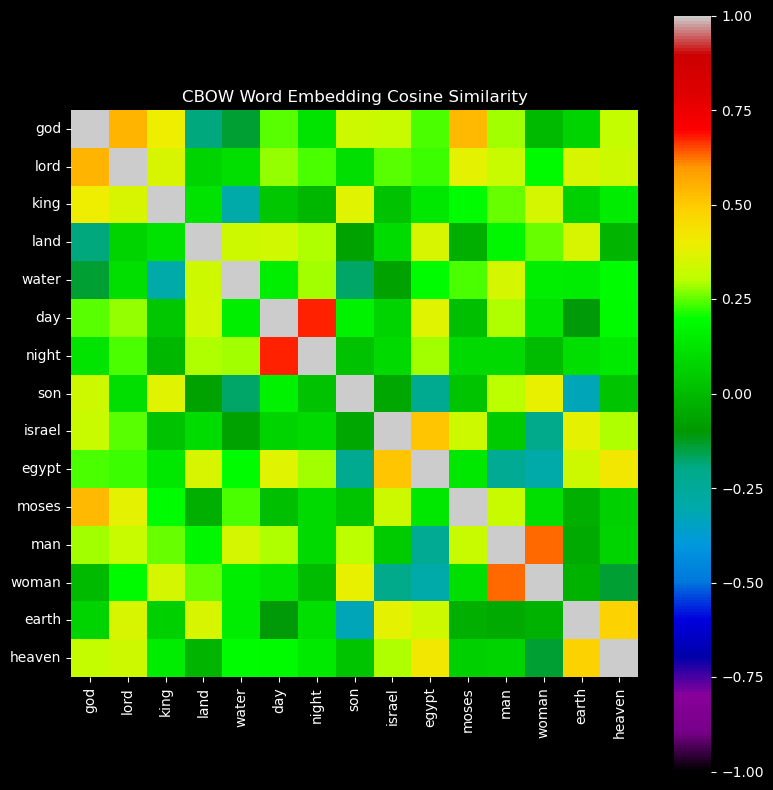

In [11]:
plot_words = ["god", "lord", "king", "land", "water", "day", "night", "son",
              "israel", "egypt", "moses", "man", "woman", "earth", "heaven"]
plot_words = [w for w in plot_words if w in word_to_idx]  # keep only words that survived filtering

plot_vecs = np.array([embedding_weights[word_to_idx[w]] for w in plot_words])
cosine_sim = cosine_similarity(plot_vecs)

fig, ax = plt.subplots(figsize=(8, 8))
sns.heatmap(cosine_sim, square=True, cbar=True, vmin=-1, vmax=1, cmap="nipy_spectral",
            xticklabels=plot_words, yticklabels=plot_words, ax=ax)
ax.set_title("CBOW Word Embedding Cosine Similarity")
plt.tight_layout()
plt.show()


### 4.2 PCA scatter plot

Project the same word vectors down to 2D with PCA and label each point — words the model
treats as interchangeable in context should cluster together.

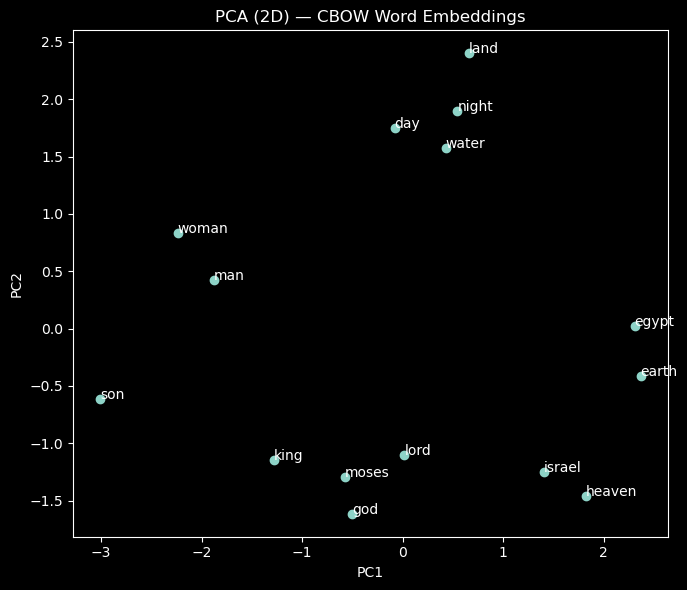

In [12]:
from sklearn.decomposition import PCA

pca_2d = PCA(n_components=2, random_state=0).fit_transform(plot_vecs)

plt.figure(figsize=(7, 6))
plt.scatter(pca_2d[:, 0], pca_2d[:, 1])
for i, w in enumerate(plot_words):
    plt.annotate(w, (pca_2d[i, 0], pca_2d[i, 1]))
plt.title("PCA (2D) — CBOW Word Embeddings")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.show()


## 5. Review

This notebook built a word-embedding model completely from scratch — no pretrained
weights, no external embedding service, just the King James Bible and a plain word2vec
architecture in Keras.

- We cleaned raw verse text into a single token stream (Section 1), just like the Bible
  example in `U1-1_Embeddings-3_Text.ipynb`, then filtered out rare words and built
  (context, target) training pairs with a sliding window.
- We started with plain **CBOW** (average the context words, predict the missing center
  word), which produced fairly noisy neighbor lists on this small, proper-noun-heavy
  corpus. Adding a nonlinear hidden layer made it measurably *worse* — the softmax could
  offload work that should live in the embedding matrix itself. Switching to **skip-gram**
  (predict each context word individually from the center word) gave by far the best
  results we've seen: higher similarities and thematically tight neighbor lists (e.g.
  "moses" → aaron, murmurings; "king" → chedorlaomer, sodom, straight out of the Genesis
  14 war narrative).
- This version (Section 2) returns to CBOW but replaces averaging with `Flatten`, which
  concatenates the context embeddings in order instead of blending them — a
  recurrence-free way to test whether *order-blindness*, not the choice of CBOW over
  skip-gram, was the real limitation. A couple of `Conv1D` layers are stubbed in
  (commented out) for a future experiment with local n-gram patterns in the context
  window, and the extracted embedding matrix (Section 3) is now standard-scaled before any
  cosine-similarity or PCA calculation, so no single dimension's raw magnitude can
  dominate those comparisons.
- The heatmap and PCA plot (Section 4) show the same relationships visually, echoing the
  cosine-similarity and PCA visualizations used elsewhere in Unit 1 and Unit 3.

**Limitations worth discussing in class:** the corpus here (`n_verses` verses) is tiny
compared to real word2vec training runs (billions of tokens), the vocabulary is filtered
aggressively to keep the softmax layer small, and King James English is archaic and
repetitive — all of which make these embeddings noisier than something like GloVe or a
modern sentence transformer. `Flatten` also makes the output `Dense` layer `context_size`
times larger than averaging did, which is expected to overfit faster on a corpus this
small — worth watching for when this cell is actually run. The bigger lesson from this
whole notebook: the "obvious" or textbook-default architecture (CBOW) isn't always the
right choice once you actually look at what the data and vocabulary look like, and there's
more than one way to fix a given weakness (switch prediction direction vs. preserve order
directly) — they're not guaranteed to be equally effective.
